In [1]:

import numpy as np
import pandas as pd
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter


In [2]:
df_reddit=pd.read_csv("reddit_lemmen.csv")
df_reddit

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,post_length,num_comments_length,year,month,post_lemmas,comment_lemmas,post_title_lemmas
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,834,125,2024,6,"['fucking', 'kill', 'shoot', 'wish', 'bed', 'f...","['life', 'overall', 'shitty', 'borderline', 'u...","['I', 'wish', 'someone', 'would', 'just', '...']"
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,38,145,2024,6,"['feel', 'apt', 'description', 'hear', 'feel',...","['younger', 'lowest', 'say', 'home', 'get', 'o...","['a', 'friend', 'of', 'mine', 'once', 'describ..."
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,245,97,2024,9,"['destroy', 'think', 'maybe', 'severely', 'dep...","['stew', 'hour', 'constantly', 'gutte', 'life'...","['Therapist', 'explain', 'to', 'I', 'that', 'n..."
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,171,122,2024,10,"['try', 'guess', 'care', 'busy', 'life', 'prob...","['do', 'care', 'dump', 'issue', 'burden', 'lit...","['everyone', 'say', 'if', 'you', 'be', 'depres..."
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,369,55,2024,10,"['quiet', 'quit', 'life', 'realize', 'friend',...","['man', 'holy', 'shit', 'relate', 'life', 'rig...","['quiet', 'quit', 'life']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48399,49399,1m6hd27,BPD,Are you literally a now or never person?,"Hi guys, so I almost always refuse to do thin...",2025-07-23 01:06:43,['Yes I hate that I can be like this. I will h...,new,guys refuse things wanna unless right fuck min...,yes hate hold having conversations need wait e...,177,88,2025,7,"['guy', 'refuse', 'thing', 'wanna', 'unless', ...","['yes', 'hate', 'hold', 'have', 'conversation'...","['be', 'you', 'literally', 'a', 'now', 'or', '..."
48400,49400,1m6fxg9,BPD,happy cake day to me 🥳,it's been a year since i decided to explore th...,2025-07-23 00:12:25,"['Schizoid here, happy cake day :)', 'BPD, ADH...",new,decided explore little section internet pseudo...,schizoid happy cake bpd adhd anxiety narcissis...,149,9,2025,7,"['decide', 'explore', 'little', 'section', 'in...","['schizoid', 'happy', 'cake', 'bpd', 'adhd', '...","['happy', 'cake', 'day', 'to', 'I', '🥳']"
48401,49401,1m6f2uq,BPD,I am feeling like a dumbass right now,A girl behind me was in great pain because of ...,2025-07-22 23:38:38,[' Been there. Sometimes when our own systems...,new,girl great pain fibromialgia started crying re...,systems overload barely enuf bucket care look ...,184,74,2025,7,"['girl', 'great', 'pain', 'fibromialgia', 'sta...","['system', 'overload', 'barely', 'enuf', 'buck...","['I', 'be', 'feel', 'like', 'a', 'dumbass', 'r..."
48402,49402,1m6ee0g,BPD,"Mom wouldn’t play with me, so I made up someon...","When I was a kid, I just wanted my mom to p

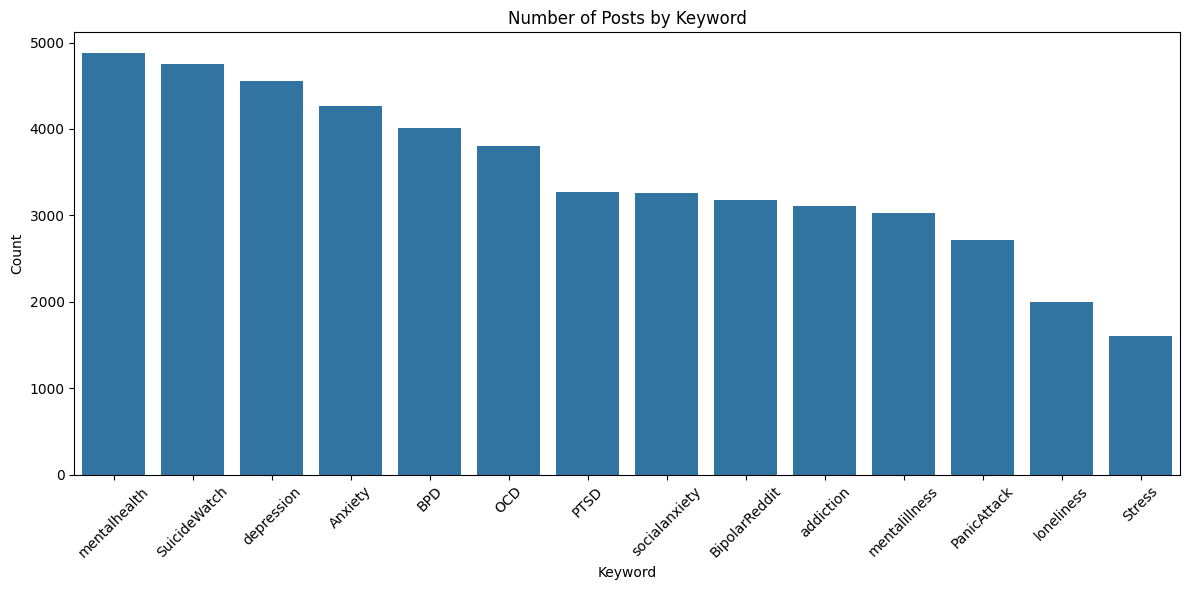

,Keyword,Count
0,mentalhealth,4874
1,SuicideWatch,4751
2,depression,4555
3,Anxiety,4266
4,BPD,4012
5,OCD,3800
6,PTSD,3269
7,socialanxiety,3253
8,BipolarReddit,3174
9,addiction,3109


In [3]:
# NUMBER OF POSTS WITH EACH KEYWORD
df_reddit = df_reddit[df_reddit['keyword'].notna()]
keyword_counts = df_reddit['keyword'].value_counts()
plt.figure(figsize=(12, 6))
# CREATE A DATAFRAME FOR THE KEYWORDS AND THEIR COUNTS
keyword_df = pd.DataFrame({
    'Keyword': keyword_counts.index,
    'Count': keyword_counts.values
})
sns.barplot(data=keyword_df, x='Keyword', y='Count')
plt.title('Number of Posts by Keyword')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
keyword_df

In [4]:
def get_top_ngrams(corpus, ngram_range=(2, 2), n=None):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:n]

In [5]:
df_reddit['post_content'] = df_reddit['post_title'].fillna('') + ' ' + df_reddit['post_text'].fillna('')
top_bigrams = get_top_ngrams(df_reddit['post_content'], ngram_range=(2, 2), n=15)
top_trigrams = get_top_ngrams(df_reddit['post_content'], ngram_range=(3, 3), n=15)


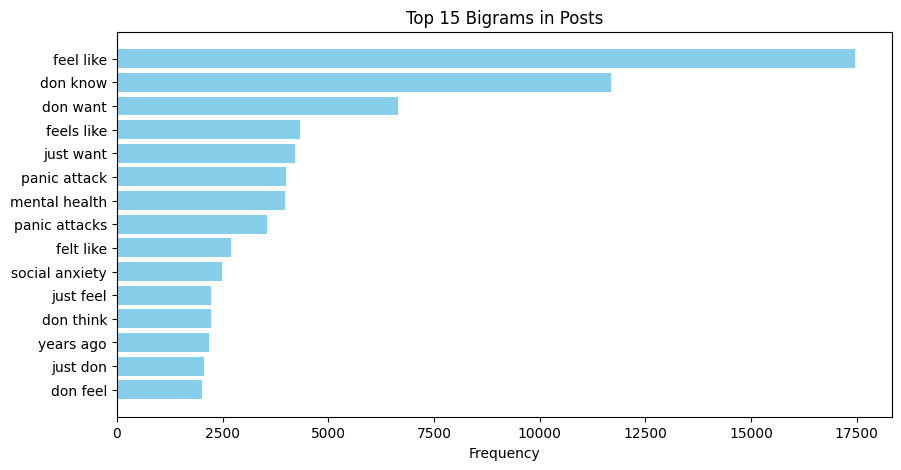

In [6]:
def plot_ngrams(ngrams, title):
    labels, values = zip(*ngrams)
    plt.figure(figsize=(10,5))
    plt.barh(labels[::-1], values[::-1], color='skyblue')
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_ngrams(top_bigrams, "Top 15 Bigrams in Posts")


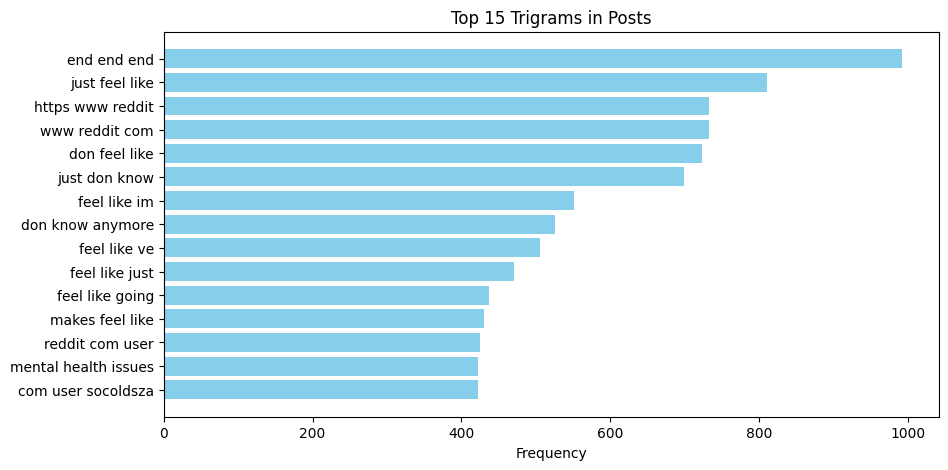

In [8]:
def plot_ngrams(ngrams, title):
    labels, values = zip(*ngrams)
    plt.figure(figsize=(10,5))
    plt.barh(labels[::-1], values[::-1], color='skyblue')
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_ngrams(top_trigrams, "Top 15 Trigrams in Posts")

In [7]:
#convert the current dataaframe to a csv file
df_reddit.to_csv("reddit_ngrams_analysis.csv", index=False)